In [85]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import joblib
from sklearn.preprocessing import LabelEncoder , OneHotEncoder
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
import seaborn as sns 

In [86]:
df = pd.read_csv(r"Walmart.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


## exploratory Data analysis 

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [88]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [89]:
print(df.duplicated().sum())

0


In [90]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [91]:
df['Weekly_Sales'].nunique()

6435

In [92]:
df['Date'] = pd.to_datetime(df['Date'],format= "%d-%m-%Y")

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_name'] = df["Date"].dt.month_name()
df['Day'] = df['Date'].dt.day
df['Week'] = df['Date'].dt.isocalendar().week
df['Quarter'] = df['Date'].dt.quarter

df.drop('Date',axis=1, inplace=True)

In [93]:
df.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Month_name,Day,Week,Quarter
0,1,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,February,5,5,1
1,1,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,February,12,6,1
2,1,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,February,19,7,1
3,1,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,February,26,8,1
4,1,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,March,5,9,1


In [94]:
monthly_sales = df.groupby("Month_name")['Weekly_Sales'].sum()


print(monthly_sales.sort_values(ascending= False))

Month_name
July         6.500010e+08
April        6.468598e+08
June         6.226299e+08
August       6.130902e+08
March        5.927859e+08
October      5.847848e+08
September    5.787612e+08
December     5.768386e+08
February     5.687279e+08
May          5.571256e+08
November     4.130157e+08
January      3.325984e+08
Name: Weekly_Sales, dtype: float64


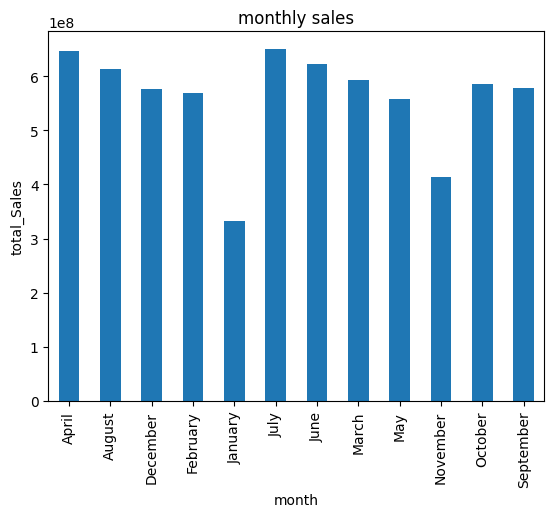

In [95]:
monthly_sales.plot(kind='bar')

plt.title("monthly sales")
plt.xlabel("month")
plt.ylabel("total_Sales")

plt.show()

In [96]:
yearly_sales = df.groupby('Year')['Weekly_Sales'].sum()

print(yearly_sales)

Year
2010    2.288886e+09
2011    2.448200e+09
2012    2.000133e+09
Name: Weekly_Sales, dtype: float64


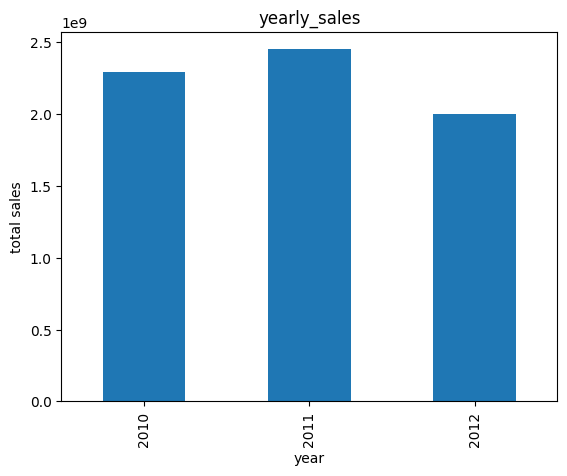

In [97]:
yearly_sales.plot(kind='bar')

plt.title("yearly_sales")
plt.xlabel('year')
plt.ylabel('total sales')
plt.show()


In [98]:
print(monthly_sales.idxmax())

July


In [99]:
print(monthly_sales.idxmin())

January


In [100]:
print(df.dtypes)

Store             int64
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
Year              int32
Month             int32
Month_name       object
Day               int32
Week             UInt32
Quarter           int32
dtype: object


In [101]:
df['Month_name'].unique()

array(['February', 'March', 'April', 'May', 'June', 'July', 'August',
       'September', 'October', 'November', 'December', 'January'],
      dtype=object)

In [102]:
df['Month'].unique()

array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1], dtype=int32)

In [103]:
df.drop('Month_name', axis=1, inplace=True)

## corr relation 

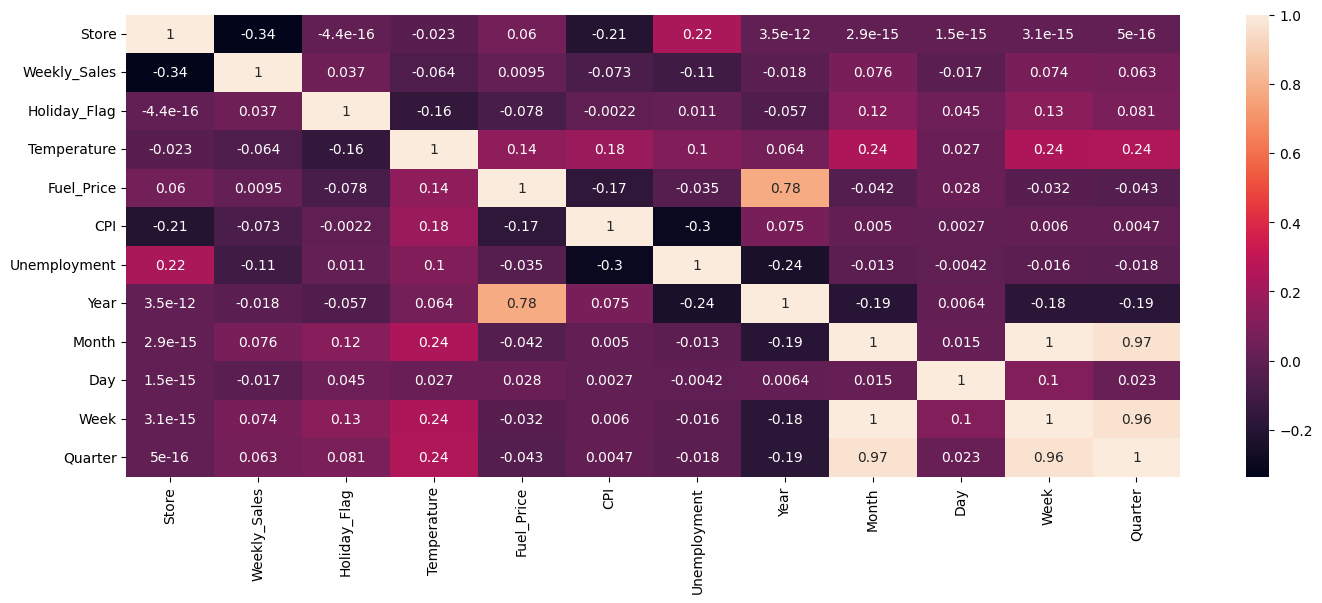

In [104]:
plt.figure(figsize=(17,6))

sns.heatmap(df.corr(),annot=True)

plt.show()

In [105]:
df.duplicated().sum()

np.int64(0)

## Define target Feature

In [106]:
x = df.drop("Weekly_Sales",axis=1)

y = df['Weekly_Sales']


In [107]:
x_train,x_test,y_train,y_test = train_test_split(
  x,y, test_size=0.3, random_state=42)


### We used XGBoost for best model 


In [108]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import  RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import r2_score,accuracy_score

In [109]:
models = {
  'linear' : LinearRegression(),
  'DecisionTreeRegressor' : DecisionTreeRegressor(),
  'RandomForestRegressor' : RandomForestRegressor(),
  'XGBRegressor' : XGBRegressor()
}

In [111]:
for name , model in models .items():
  model.fit(x_train,y_train)


  print("=-==-=-=-=-=-=-===-=-=-=-=-=-==--=-==-=")



  y_pred = model.predict(x_test)

  print("-=--=-=-=-=-=-=-=-=-=-=-=-=-")

  score = r2_score(y_test,y_pred)

  print("R2score",round(score,2))

  print("=-==-=-=-=-=-=-===-=-=-=-=-=-==--=-==-=")


=-==-=-=-=-=-=-===-=-=-=-=-=-==--=-==-=
-=--=-=-=-=-=-=-=-=-=-=-=-=-
R2score 0.16
=-==-=-=-=-=-=-===-=-=-=-=-=-==--=-==-=
=-==-=-=-=-=-=-===-=-=-=-=-=-==--=-==-=
-=--=-=-=-=-=-=-=-=-=-=-=-=-
R2score 0.95
=-==-=-=-=-=-=-===-=-=-=-=-=-==--=-==-=
=-==-=-=-=-=-=-===-=-=-=-=-=-==--=-==-=
-=--=-=-=-=-=-=-=-=-=-=-=-=-
R2score 0.96
=-==-=-=-=-=-=-===-=-=-=-=-=-==--=-==-=
=-==-=-=-=-=-=-===-=-=-=-=-=-==--=-==-=
-=--=-=-=-=-=-=-=-=-=-=-=-=-
R2score 0.98
=-==-=-=-=-=-=-===-=-=-=-=-=-==--=-==-=


In [114]:
best_score = r2_score(y_pred,y_test)
print(round(best_score,2))

import joblib 

joblib.dump(best_score,"best_score.joblib")

0.98


['best_score.joblib']

In [118]:
model = joblib.load("best_score.joblib")